### 1. Import and Load Data

In [1]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

df = pd.read_csv("../data/saas_churn_data.csv")

df.head()

,customer_id,plan_type,country,company_size,days_active_last_30,last_login_days_ago,features_used,team_members_added,support_tickets,billing_issues,subscription_age_months,emails_opened_last_30,training_completed,monthly_fee,signup_date,churned
0,CUST-1,Starter,Canada,Small,20,28,1,20,1,0,31,7,0,29,2025-07-26,0
1,CUST-2,Enterprise,Nigeria,Medium,16,5,4,15,1,0,19,1,1,249,2025-03-24,0
2,CUST-3,Pro,Canada,Small,14,21,5,14,3,0,24,3,0,79,2024-10-08,0
3,CUST-4,Starter,US,Large,5,2,9,4,2,0,9,9,1,29,2025-11-05,0
4,CUST-5,Free,US,Small,15,9,7,5,3,0,23,12,1,0,2024-02-26,0


### 2. Select features and target variables

In [3]:
features = [
    "plan_type",
    "company_size",
    "days_active_last_30",
    "last_login_days_ago",
    "features_used",
    "team_members_added",
    "support_tickets",
    "billing_issues",
    "subscription_age_months",
    "emails_opened_last_30",
    "training_completed",
    "monthly_fee"
]

X = df[features]
y = df["churned"]

### 3. Encode categorical columns

In [4]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,days_active_last_30,last_login_days_ago,features_used,team_members_added,support_tickets,billing_issues,subscription_age_months,emails_opened_last_30,training_completed,monthly_fee,plan_type_Free,plan_type_Pro,plan_type_Starter,company_size_Medium,company_size_Small
0,20,28,1,20,1,0,31,7,0,29,False,False,True,False,True
1,16,5,4,15,1,0,19,1,1,249,False,False,False,True,False
2,14,21,5,14,3,0,24,3,0,79,False,True,False,False,True
3,5,2,9,4,2,0,9,9,1,29,False,False,True,False,False
4,15,9,7,5,3,0,23,12,1,0,True,False,False,False,True


### 4. Split data into train and test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 5. Train balanced Logistic Regression Model

In [6]:
balanced_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### 6. Generate Predictions

In [7]:
y_pred = balanced_log_model.predict(X_test)
y_proba = balanced_log_model.predict_proba(X_test)[:, 1]

In [8]:
y_proba[:5]

array([0.40364775, 0.45756327, 0.56604232, 0.21199915, 0.39532101])

y_pred = final class prediction
- 0 means not churned
- 1 means churned

y_proba = churn probability
- Example: 0.72 means 72% churn risk

### 7. Classification Report

The classification report shows how well the selected Balanced Logistic Regression model performs on both customer groups: customers who stayed and customers who churned.

For this project, the most important class is the churned customer group. The goal is to identify customers who are likely to leave so that the business can take action early.

Recall is especially important because it shows how many actual churned customers the model was able to detect.

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

              precision    recall  f1-score   support

 Not Churned       0.86      0.67      0.75       288
     Churned       0.46      0.71      0.56       112

    accuracy                           0.69       400
   macro avg       0.66      0.69      0.66       400
weighted avg       0.75      0.69      0.70       400



### Classification Report Interpretation

The Balanced Logistic Regression model achieved an overall accuracy of 69% on the test set.

For customers who churned, the model achieved a recall of 71%. This means it was able to identify about 71% of the customers who actually churned. This is important for a churn prediction use case because the business wants to detect at-risk customers early and take retention action.

The precision for churned customers was 46%, meaning that some customers flagged as churn risks may not actually churn. However, this trade-off is acceptable in this project because the model is intended to support customer success teams by highlighting customers who need attention, rather than making automatic decisions.

Overall, the model is useful for the RetentionIQ dashboard because it prioritises detecting churn risk, which aligns with the business goal of reducing customer churn.
    

### 8. Confusion Matrix

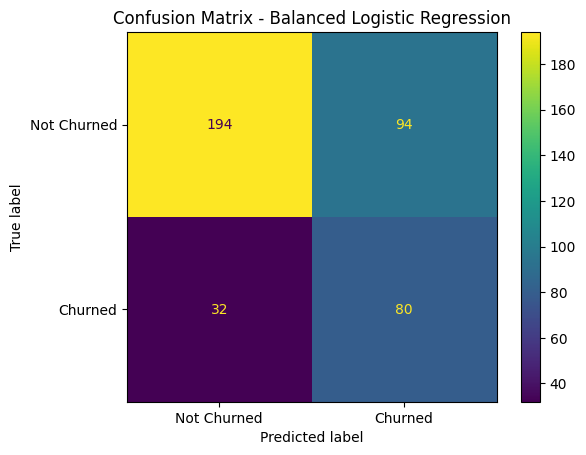

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

display.plot()
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

Interpretation

- Top-left: customers who stayed and the model correctly predicted stayed               194
- Top-right: customers who stayed but the model wrongly predicted churn                  94
- Bottom-left: customers who churned but the model wrongly predicted stayed              32
- Bottom-right: customers who churned and the model correctly predicted churn            80

### Confusion Matrix Interpretation

The confusion matrix gives a clearer view of how the model performed on the test data.

The model correctly identified 194 customers who did not churn and correctly caught 80 customers who actually churned. This means the model successfully detected most of the churned customers in the test set.

However, the model also wrongly flagged 94 customers as churn risks even though they did not churn. These are false positives. In a retention use case, this is acceptable to some extent because these customers can simply be reviewed or monitored by the customer success team.

The model missed 32 customers who actually churned. These are false negatives, and they are the most important errors in this project because they represent customers the business failed to identify before they left.

Overall, the model is useful because it caught 80 out of 112 churned customers, giving it a churn recall of about 71%. This supports the goal of RetentionIQ, which is to identify at-risk customers early and help the business take retention action.

### 9. ROC_AUC Score

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)
roc_auc

0.7581845238095238

### ROC-AUC Interpretation

The model achieved a ROC-AUC score of approximately 0.758.

ROC-AUC measures how well the model separates customers who churned from customers who did not churn. A score of 0.5 would mean the model is no better than random guessing, while a score closer to 1.0 means stronger separation.

A score of 0.758 suggests that the model has a decent ability to distinguish between churned and non-churned customers. For this MVP project, this is a useful result and supports using the model as the foundation for the RetentionIQ dashboard.

### ROC Curve

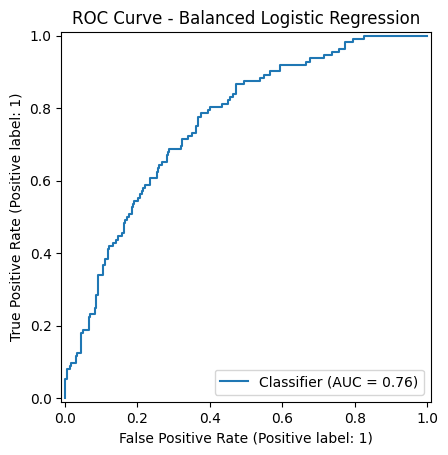

In [12]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Balanced Logistic Regression")
plt.show()

### 10. Model Coefficients

In [21]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": balanced_log_model.coef_[0]
})

coefficients["absolute_value"] = coefficients["coefficient"].abs()

top_coefficients = coefficients.sort_values(
    "absolute_value",
    ascending=False
).head(10)

top_coefficients

,feature,coefficient,absolute_value
5,billing_issues,0.834919,0.834919
8,training_completed,-0.645263,0.645263
11,plan_type_Pro,0.265570,0.265570
12,plan_type_Starter,-0.229678,0.229678
14,company_size_Small,0.214530,0.214530
13,company_size_Medium,0.156736,0.156736
2,features_used,-0.155029,0.155029
4,support_tickets,0.094639,0.094639
1,last_login_days_ago,0.055191,0.055191
0,days_active_last_30,-0.053562,0.053562


### Model Coefficient Interpretation

The table below shows the top model coefficients from the selected Balanced Logistic Regression model.

In Logistic Regression, coefficients help explain how each feature influences the model’s churn prediction:

- A **positive coefficient** means the feature increases the likelihood of churn.
- A **negative coefficient** means the feature reduces the likelihood of churn.
- The larger the absolute value, the stronger the feature’s influence on the prediction.

| Feature | Coefficient | Interpretation |
|---|---:|---|
| `billing_issues` | 0.835 | Customers with billing issues are more likely to churn. |
| `training_completed` | -0.645 | Customers who completed training are less likely to churn. |
| `plan_type_Pro` | 0.266 | Pro users show higher churn risk compared to the reference plan. |
| `plan_type_Starter` | -0.230 | Starter users show lower churn risk compared to the reference plan. |
| `company_size_Small` | 0.215 | Small companies show slightly higher churn risk. |
| `company_size_Medium` | 0.157 | Medium companies show slightly higher churn risk. |
| `features_used` | -0.155 | Customers who use more features are less likely to churn. |
| `support_tickets` | 0.095 | More support tickets slightly increase churn risk. |
| `last_login_days_ago` | 0.055 | Customers who have not logged in recently are more likely to churn. |
| `days_active_last_30` | -0.054 | Customers with more active days are less likely to churn. |

The strongest churn driver in the model is `billing_issues`, which supports the earlier EDA finding that customers with billing problems had a higher churn rate.

The strongest churn-reducing factor is `training_completed`, suggesting that onboarding plays an important role in helping customers understand the product and stay engaged.

The model also confirms that product engagement matters. Customers who use more features and are active more often are less likely to churn, while customers with more support tickets and longer periods since their last login are more likely to churn.

Overall, the coefficient analysis shows that the model is learning patterns that make sense from a product perspective. The key churn signals are billing friction, onboarding completion, feature adoption, support issues, and customer activity.

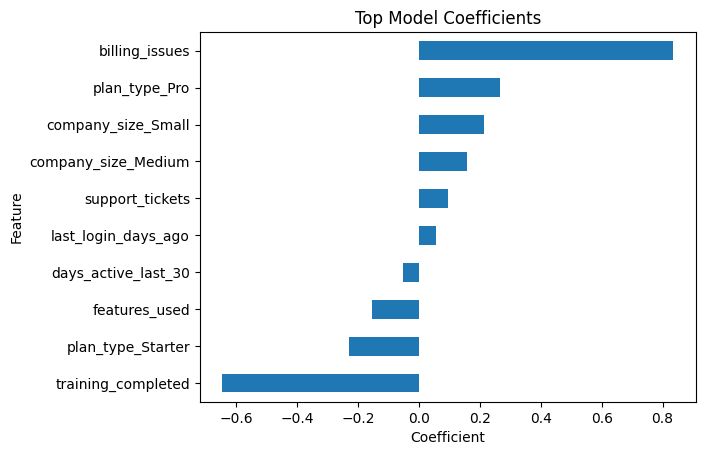

In [18]:
top_coefficients.sort_values("coefficient").plot(
    kind="barh",
    x="feature",
    y="coefficient",
    legend=False
)

plt.title("Top Model Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

This makes the model more explainable because the dashboard can later show not only the churn risk score, but also the behaviours contributing to that risk.


### Save the Model

In [22]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(balanced_log_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

### Save the Features

In [23]:
model_features = X_train.columns.tolist()

joblib.dump(model_features, "../models/model_features.pkl")

['../models/model_features.pkl']

In [24]:
os.listdir("../models")

['churn_model.pkl', 'model_features.pkl']

### Final Insights

The selected Balanced Logistic Regression model was evaluated using a classification report, confusion matrix, ROC-AUC score, ROC curve, and model coefficients.

The model achieved a ROC-AUC score of approximately 0.758, which shows a decent ability to distinguish between customers who churned and customers who stayed. The model also identified 80 out of 112 churned customers in the test set, giving it a recall of about 71%.

For this churn prediction use case, recall is especially important because the business wants to detect at-risk customers early. Although the model also produced some false positives, this is acceptable for a retention dashboard because those customers can be reviewed or monitored by the customer success team.

The trained model and feature columns were saved using Joblib. These saved files will be used later in the Streamlit app to generate churn probability scores and support retention recommendations.